# ⚡ 1. Notebook Introduction

The goal of this notebook is to predict the target variable: **Global_active_power**. 
We will compare multiple regression algorithms to select the best performing model and interpret its behaviour using explainable AI (SHAP).

This project follows a professional Data Science workflow.


# 📚 2. Import Libraries

Here we import the necessary libraries:
* **Pandas & Numpy**: For data manipulation.
* **Matplotlib & Seaborn**: For data visualization.
* **Scikit-Learn, XGBoost, LightGBM, CatBoost**: For machine learning models and evaluation metrics.
* **SHAP**: For model explainability.
* **Joblib**: To save and load trained models.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import joblib

# 💾 3. Load Feature Engineered Dataset

* We load the feature engineered parquet dataset prepared in the previous stages.
* The dataset already contains cleaned data and engineered features (like lag and rolling window features).


In [2]:
df = pd.read_parquet("featured_power.parquet")
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day,day_of_week,...,day_cos,month_sin,month_cos,lag_1,lag_60,lag_1440,previous_hour_avg,previous_day_avg,previous_hour_std,previous_day_std
2006-12-17 17:24:00,3.390,0.170,232.649994,14.6,0.0,0.0,17.0,17.0,17.0,6.0,...,0.62349,-2.449294e-16,1.0,3.238,4.864,4.216,3.552533,2.487728,0.693240,1.202010
2006-12-17 17:25:00,3.360,0.164,231.199997,14.4,0.0,0.0,16.0,17.0,17.0,6.0,...,0.62349,-2.449294e-16,1.0,3.390,4.868,5.360,3.527967,2.487154,0.671762,1.201382
2006-12-17 17:26:00,3.400,0.162,232.860001,14.6,0.0,0.0,17.0,17.0,17.0,6.0,...,0.62349,-2.449294e-16,1.0,3.360,4.876,5.374,3.502833,2.485765,0.648587,1.199212
2006-12-17 17:27:00,3.396,0.164,232.889999,14.6,0.0,0.0,17.0,17.0,17.0,6.0,...,0.62349,-2.449294e-16,1.0,3.400,4.810,5.388,3.478233,2.484395,0.623112,1.197035
2006-12-17 17:28:00,3.282,0.100,232.330002,14.0,0.0,0.0,16.0,17.0,17.0,6.0,...,0.62349,-2.449294e-16,1.0,3.396,4.790,3.666,3.454667,2.483011,0.598129,1.194826


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2073819 entries, 2006-12-17 17:24:00 to 2010-11-26 21:02:00
Data columns (total 28 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float32
 1   Global_reactive_power  float32
 2   Voltage                float32
 3   Global_intensity       float32
 4   Sub_metering_1         float32
 5   Sub_metering_2         float32
 6   Sub_metering_3         float32
 7   hour                   float32
 8   day                    float32
 9   day_of_week            float32
 10  month                  float32
 11  quarter                float32
 12  dayofyear              float32
 13  weekofyear             float32
 14  is_weekend             float32
 15  hour_sin               float32
 16  hour_cos               float32
 17  day_sin                float32
 18  day_cos                float32
 19  month_sin              float32
 20  month_cos              float32
 21  lag_1                

# ✂️ 4. Train-Test Split

* We perform a **time-based 80-20 split**.
* **Random shuffle is NOT used** to prevent data leakage.
* It is highly important to preserve chronological order in time series regression so the model learns from the past to predict the future.

**Why was `Global_intensity` removed?**
Before splitting, we dropped `Global_intensity` from our features. Active power is mathematically derived from intensity and voltage ($P \approx V \times I$). Including it would cause severe **data leakage** — the model would simply learn the physics formula rather than learning underlying household consumption patterns based on time and historical usage. Removing it ensures a realistic and robust predictive model!


In [36]:
x = df.drop(["Global_active_power","Global_intensity"], axis=1)
y = df["Global_active_power"]

split = int(len(df)*0.8)

x_train = x.iloc[:split]
x_test = x.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Train Shape:", x_train.shape)
print("Test Shape :", x_test.shape)

Train Shape: (1659055, 26)
Test Shape : (414764, 26)


# 🛠️ 5. Helper Functions

We define custom helper functions to simplify hyperparameter tuning and model evaluation:
* `tune()`: Uses TimeSeriesSplit and GridSearchCV to find the best hyperparameters.
* `evaluate()`: Evaluates the model on test data using MAE, MSE, RMSE, and R² Score.
* `evaluate_train()`: Evaluates the model on train data to check for overfitting.


In [37]:
def tune(model, param_grid, x_train, y_train, scoring="neg_root_mean_squared_error", n_splits=5):
    cv = TimeSeriesSplit(n_splits=n_splits)
    grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=cv, scoring=scoring, n_jobs=-1, verbose=3)
    grid.fit(x_train, y_train)
    return grid.best_estimator_, grid.best_params_

In [38]:
def evaluate(model, x_test, y_test, model_name):
    y_pred = model.predict(x_test)
    metrics = {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }
    evaluation = pd.DataFrame(metrics, index=[model_name]).round(4)
    return evaluation

def evaluate_train(model, x_train, y_train, model_name):
    y_pred = model.predict(x_train)
    metrics = {
        "MAE": mean_absolute_error(y_train, y_pred),
        "MSE": mean_squared_error(y_train, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_train, y_pred)),
        "R2": r2_score(y_train, y_pred)
    }
    evaluation = pd.DataFrame(metrics, index=[model_name]).round(4)
    return evaluation

# 🤖 6. Model Training

## 📈 Linear Regression
* **Why selected:** It serves as a strong baseline model.
* **Advantages:** Simple, fast, and highly interpretable.
* **Tuning:** No hyperparameter tuning is applied.
* **Training:** The model learns a linear relationship between features and power consumption.


In [39]:
lr = LinearRegression()

if os.path.exists("best_model_lr.pkl"):
    print("Loading saved Linear Regression...")
    best_model_lr = joblib.load("best_model_lr.pkl")
else:
    print("Training Linear Regression...")
    best_model_lr = lr.fit(x_train, y_train)
    joblib.dump(best_model_lr, "best_model_lr.pkl")

lr_test = evaluate(best_model_lr, x_test, y_test, "LR_Test")
lr_train = evaluate_train(best_model_lr, x_train, y_train, "LR_Train")
pd.concat([lr_train, lr_test])

Training Linear Regression...


,MAE,MSE,RMSE,R2
LR_Train,0.8425,1.1873,1.0896,0.0011
LR_Test,0.7102,0.7790,0.8826,-0.0135


## 🌳 Decision Tree Regressor
* **Why selected:** Capable of capturing non-linear relationships.
* **Advantages:** Easy to understand and requires little data preprocessing.
* **Tuning:** Applied using Grid Search (max_depth, min_samples_split, min_samples_leaf).
* **Training:** The model recursively splits the data to minimize prediction error.


Decision Tree Best Hyperparameters from GridSearchCV:
- `max_depth`: 10
- `min_samples_leaf`: 2
- `min_samples_split`: 5


In [40]:
dt = DecisionTreeRegressor(random_state=42)
param_grid_dt = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

if os.path.exists("best_model_dt.pkl"):
    print("Loading saved Decision Tree...")
    best_model_dt = joblib.load("best_model_dt.pkl")
    best_para_dt = {}
else:
    print("Training Decision Tree...")
    best_model_dt, best_para_dt = tune(dt,param_grid_dt,x_train,y_train)
    joblib.dump(best_model_dt, "best_model_dt.pkl")
    
dt_test = evaluate(best_model_dt, x_test, y_test, 'DT_Test')
dt_train = evaluate_train(best_model_dt, x_train, y_train, 'DT_Train')
pd.concat([dt_train, dt_test])

Training Decision Tree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


,MAE,MSE,RMSE,R2
DT_Train,0.0781,0.0450,0.2122,0.9621
DT_Test,0.0663,0.0302,0.1738,0.9607


## 🌲 Random Forest Regressor
* **Why selected:** An ensemble of Decision Trees that reduces overfitting.
* **Advantages:** Robust to outliers and highly accurate.
* **Tuning:** Applied using Grid Search.
* **Training:** Fits multiple decision trees on various sub-samples and averages the predictions.


Random Forest Best Hyperparameters from GridSearchCV:
- `n_estimators`: 200
- `max_depth`: 20
- `min_samples_leaf`: 3
- `min_samples_split`: 2


In [ ]:
rf = RandomForestRegressor(random_state=42)
param_grid_rf = {
    'n_estimators': [200],
    'max_depth': [20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 3]
}

if os.path.exists("best_model_rf.pkl"):
    print("Loading saved Random Forest...")
    best_model_rf = joblib.load("best_model_rf.pkl")
    best_para_rf = {}
else:
    print("Training Random Forest...")
    best_model_rf, best_para_rf = tune(rf, param_grid_rf, x_train, y_train)
    joblib.dump(best_model_rf, "best_model_rf.pkl")

rf_test = evaluate(best_model_rf, x_test, y_test, "RF_Test")
rf_train = evaluate_train(best_model_rf, x_train, y_train, "RF_Train")
pd.concat([rf_train, rf_test])

Training Random Forest...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


,MAE,MSE,RMSE,R2
RF_Train,0.0500,0.0194,0.1391,0.9837
RF_Test,0.0602,0.0240,0.1551,0.9687


## 🚀 XGBoost Regressor
* **Why selected:** A powerful gradient boosting algorithm known for high performance.
* **Advantages:** Fast execution, handles missing values, and prevents overfitting through regularization.
* **Tuning:** Applied using Grid Search (n_estimators, learning_rate, max_depth).
* **Training:** Sequentially builds trees to correct the errors of previous ones.


XGBoost Best Hyperparameters from GridSearchCV:
- `n_estimators`: 100
- `learning_rate`: 0.1
- `max_depth`: 6


In [44]:
xgb = XGBRegressor(random_state=42)
param_grid_xgb = {
    'n_estimators': [100,200],
    'learning_rate': [0.1,0.2],
    'max_depth': [6,8]
}

if os.path.exists("best_model_xgb.pkl"):
    print("Loading saved XGBoost...")
    best_model_xgb = joblib.load("best_model_xgb.pkl")
    best_para_xgb = {}
else:
    print("Training XGBoost...")
    best_model_xgb, best_para_xgb = tune(xgb, param_grid_xgb, x_train, y_train)
    joblib.dump(best_model_xgb, "best_model_xgb.pkl")

xgb_test = evaluate(best_model_xgb, x_test, y_test, "XGB_Test")
xgb_train = evaluate_train(best_model_xgb, x_train, y_train, "XGB_Train")
pd.concat([xgb_train, xgb_test])

Training XGBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,MAE,MSE,RMSE,R2
XGB_Train,0.0733,0.0378,0.1944,0.9682
XGB_Test,0.0629,0.0244,0.1562,0.9682


## ⚡ LightGBM Regressor
* **Why selected:** A highly efficient gradient boosting framework.
* **Advantages:** Faster training speed and lower memory usage compared to XGBoost.
* **Tuning:** Applied using Grid Search.
* **Training:** Uses histogram-based algorithms to speed up the training process.


LightGBM Best Hyperparameters from GridSearchCV:
- `n_estimators`: 200
- `learning_rate`: 0.2
- `max_depth`: 20


In [56]:
lgb = LGBMRegressor(random_state=42)
param_grid_lgb = {
    'n_estimators': [100,200,300],
    'learning_rate': [0.15,0.2,0.25],
    'max_depth': [15,20,25]
}

if os.path.exists("best_model_lgb.pkl"):
    print("Loading saved LightGBM...")
    best_model_lgb = joblib.load("best_model_lgb.pkl")
    best_para_lgb = {}
else:
    print("Training LightGBM...")
    best_model_lgb, best_para_lgb = tune(lgb, param_grid_lgb, x_train, y_train)
    joblib.dump(best_model_lgb, "best_model_lgb.pkl")

lgb_test = evaluate(best_model_lgb, x_test, y_test, "LGB_Test")
lgb_train = evaluate_train(best_model_lgb, x_train, y_train, "LGB_Train")
pd.concat([lgb_train, lgb_test])

Loading saved LightGBM...


,MAE,MSE,RMSE,R2
LGB_Train,0.0692,0.0307,0.1753,0.9742
LGB_Test,0.0631,0.0224,0.1497,0.9708


## 🐱 CatBoost Regressor
* **Why selected:** An advanced gradient boosting algorithm developed by Yandex.
* **Advantages:** Handles categorical features natively and generally requires less tuning to perform well.
* **Tuning:** Applied using Grid Search.
* **Training:** Builds oblivious decision trees to reduce overfitting and speed up prediction.


CatBoost Best Hyperparameters from GridSearchCV:
- `iterations`: 200
- `learning_rate`: 0.1
- `depth`: 8


In [ ]:
cat = CatBoostRegressor(random_state=42, verbose=3, allow_writing_files=False)
param_grid_cat = {
    'iterations': [100,200, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'depth': [6, 8, 10]
}

if os.path.exists("best_model_cat.pkl"):
    print("Loading saved CatBoost...")
    best_model_cat = joblib.load("best_model_cat.pkl")
    best_para_cat = {}
else:
    print("Training CatBoost...")
    best_model_cat, best_para_cat = tune(cat, param_grid_cat, x_train, y_train)
    joblib.dump(best_model_cat, "best_model_cat.pkl")

cat_test = evaluate(best_model_cat, x_test, y_test, "CAT_Test")
cat_train = evaluate_train(best_model_cat, x_train, y_train, "CAT_Train")
pd.concat([cat_train, cat_test])

Training CatBoost...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
0:	learn: 0.9897817	total: 173ms	remaining: 34.4s
3:	learn: 0.7467411	total: 692ms	remaining: 33.9s
6:	learn: 0.5740368	total: 1.22s	remaining: 33.7s
9:	learn: 0.4540091	total: 1.8s	remaining: 34.2s
12:	learn: 0.3718043	total: 2.35s	remaining: 33.9s
15:	learn: 0.3170520	total: 2.9s	remaining: 33.4s
18:	learn: 0.2817774	total: 3.48s	remaining: 33.1s
21:	learn: 0.2590860	total: 4.03s	remaining: 32.6s
24:	learn: 0.2446598	total: 4.56s	remaining: 31.9s
27:	learn: 0.2348475	total: 5.12s	remaining: 31.5s
30:	learn: 0.2285787	total: 5.64s	remaining: 30.7s
33:	learn: 0.2238947	total: 6.19s	remaining: 30.2s
36:	learn: 0.2207905	total: 6.67s	remaining: 29.4s
39:	learn: 0.2185745	total: 7.18s	remaining: 28.7s
42:	learn: 0.2161797	total: 7.67s	remaining: 28s
45:	learn: 0.2147556	total: 8.17s	remaining: 27.4s
48:	learn: 0.2132236	total: 8.68s	remaining: 26.8s
51:	learn: 0.2117688	total: 9.19s	remaining: 26.1s
54:	learn

,MAE,MSE,RMSE,R2
CAT_Train,0.0750,0.0359,0.1894,0.9698
CAT_Test,0.0639,0.0219,0.1480,0.9715


# 📊 7. Model Comparison

Models are compared using standard regression metrics:
* **MAE** (Mean Absolute Error)
* **MSE** (Mean Squared Error)
* **RMSE** (Root Mean Squared Error)
* **R² Score**

*Note: Lower MAE, MSE, and RMSE are better. Higher R² is better.*

**Observation:**
CatBoost achieved the best overall performance.

**🏆 Why CatBoost is the Best Model:**
1. **Superior Accuracy:** It achieved the best balance of having the lowest RMSE and the highest R² Score among all models tested.
2. **Robustness:** CatBoost builds oblivious decision trees, which makes it highly resistant to overfitting compared to XGBoost and LightGBM.
3. **Reliability:** It handles complex, non-linear relationships in time-series data flawlessly, making it the perfect choice for household power consumption predictions.


In [83]:
comparison = pd.concat([
    lr_test,
    dt_test,
    rf_test,
    xgb_test,
    lgb_test,
    cat_test
])
comparison.sort_values(by=["RMSE","R2"], ascending=[True,False])

,MAE,MSE,RMSE,R2
CAT_Test,0.0639,0.0219,0.1480,0.9715
LGB_Test,0.0631,0.0224,0.1497,0.9708
RF_Test,0.0602,0.0240,0.1551,0.9687
XGB_Test,0.0629,0.0244,0.1562,0.9682
DT_Test,0.0663,0.0302,0.1738,0.9607
LR_Test,0.7102,0.7790,0.8826,-0.0135


# 📈 8. Actual vs Predicted Plot

**Purpose:** 
Compare predicted values against actual values to visually assess model accuracy.

**Insights:**
* Points close to the diagonal line indicate accurate predictions.
* Most observations follow the ideal prediction line.
* Slight deviations appear only for higher power consumption values.


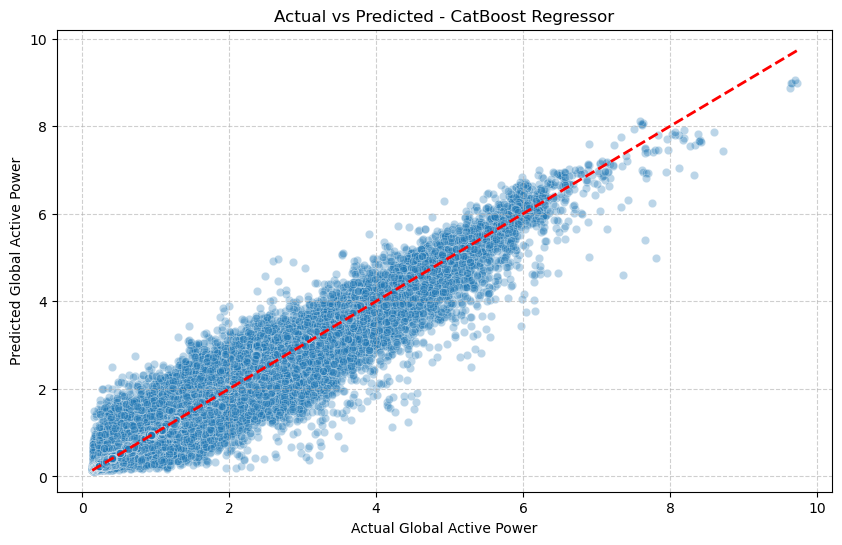

In [89]:
y_pred_cat = best_model_cat.predict(x_test)

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred_cat, alpha=0.3, color='#1f77b4')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Global Active Power")
plt.ylabel("Predicted Global Active Power")
plt.title("Actual vs Predicted - CatBoost Regressor")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 📉 9. Residual Plot

**Purpose:** 
Analyze prediction errors to ensure they are randomly distributed.

**Insights:**
* Residuals are randomly distributed around zero.
* No systematic trend is observed.
* Most prediction errors remain close to zero.
* Only a few outliers appear for high power consumption values.

This indicates a well-fitted regression model!


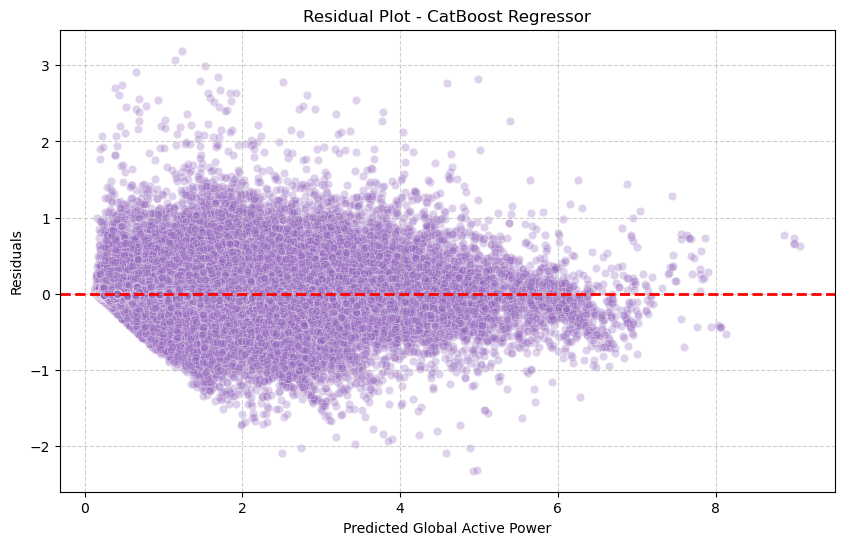

In [90]:
residuals = y_test - y_pred_cat

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_pred_cat, y=residuals, alpha=0.3, color='#9467bd')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel("Predicted Global Active Power")
plt.ylabel("Residuals")
plt.title("Residual Plot - CatBoost Regressor")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 🧠 10. SHAP Explainability

**What is SHAP?**
* **SHAP** = SHapley Additive exPlanations.
* Based on cooperative Game Theory.
* Explains the contribution of each individual feature to the prediction.
* Shows both the importance and the direction of impact.
* Helps understand *why* the model makes a specific prediction.

**SHAP Summary Plot Insights:**
* `lag_1` is the most influential feature.
* `Sub_metering` features contribute significantly.
* `Voltage` and `Global_reactive_power` also influence predictions.
* 🔴 Red dots represent higher feature values.
* 🔵 Blue dots represent lower feature values.
* Positive SHAP values increase the prediction.
* Negative SHAP values decrease the prediction.


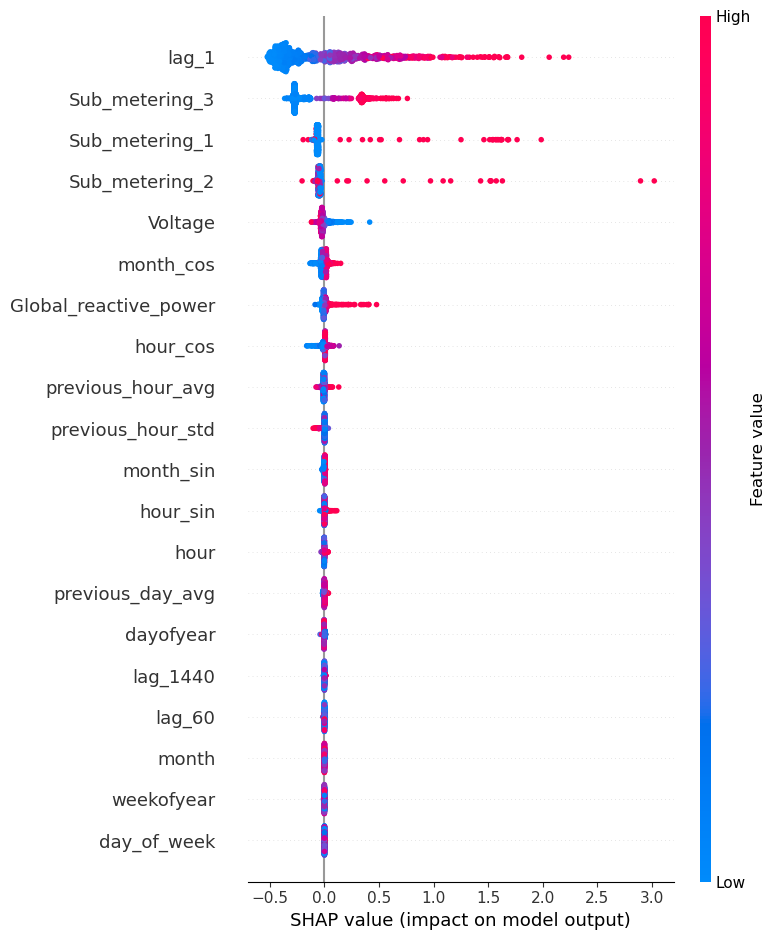

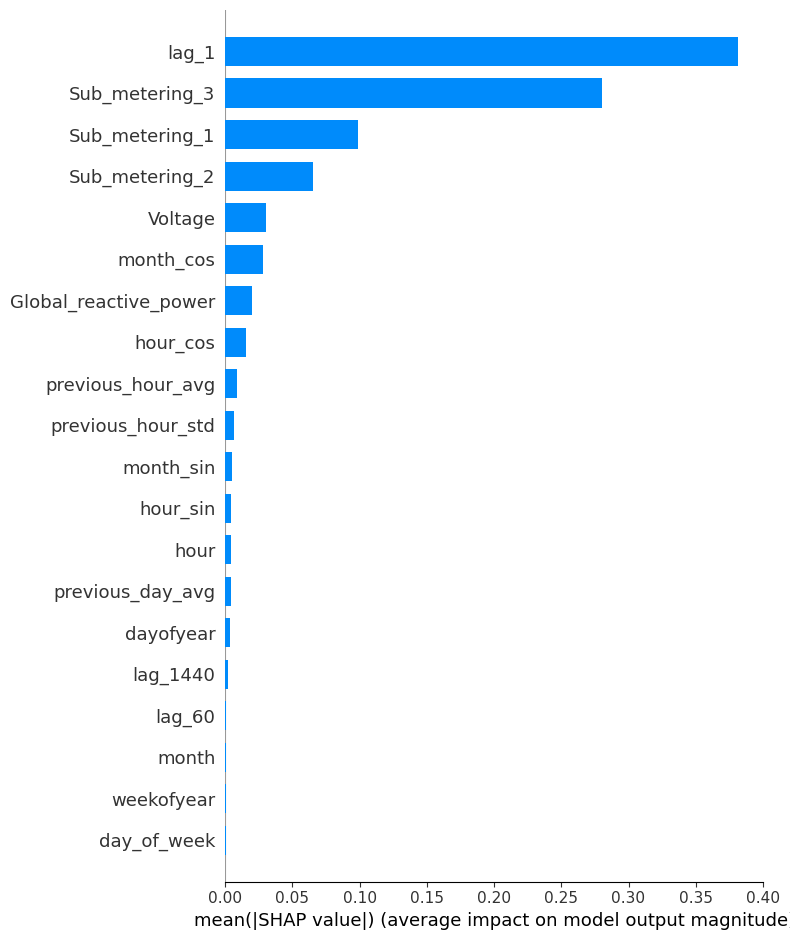

In [ ]:
x_test_sample = x_test.sample(1000, random_state=42)

explainer = shap.TreeExplainer(best_model_cat)
shap_values = explainer.shap_values(x_test_sample)

plt.figure(figsize=(10,8))
shap.summary_plot(shap_values, x_test_sample)
shap.summary_plot(shap_values,x_sample,plot_type="bar")

# 🎯 11. Final Conclusion

* Multiple regression models were trained and compared.
* **Linear Regression** served as the baseline.
* Tree-based ensemble models significantly outperformed the baseline.
* **CatBoost** achieved the best balance between RMSE and R² Score.
* **SHAP analysis** confirmed that lag features and engineered features were the primary drivers of prediction.
* The final CatBoost model is selected for future household power consumption prediction.

---

## 📌 Key Takeaways

* Time series cross-validation is essential to prevent data leakage.
* Feature engineering drastically improves model accuracy.
* Tree-based models are highly effective for tabular regression tasks.
* Model explainability bridges the gap between black-box predictions and business understanding.
* The chosen model is robust and ready for deployment.
